# ClearBank — Análise Financeira

Notebook que lê `transacoes.csv`, descarta linhas inválidas sem interromper a execução, calcula métricas mensais, lista transações acima de R$ 10.000, mostra o relatório no terminal e grava `relatorio.json`.

## Como executar no Google Colab

1. Ambiente de execução → Executar tudo.
2. O Colab abre só este notebook. A primeira célula de código cria `transacoes.csv` nesta sessão se o arquivo ainda não existir.
3. Se você já colocou um `transacoes.csv` na pasta, esse arquivo é usado.

## Saídas

- Relatório no terminal (limpeza, período, métricas mensais e suspeitas)
- `relatorio.json`
- `grafico.png` (saldo mensal)

A última célula de código é a comparação opcional com pandas (`analise_pandas.py` no repositório). Execute as células em ordem.


In [1]:
import csv
import json
from datetime import date, datetime
from pathlib import Path

LIMITE_SUSPEITO = 10000.00
TIPOS_VALIDOS = {"credito", "debito"}

CSV_PADRAO = """id,data,cliente_id,tipo,valor,descricao,categoria
1,2026-01-05,CLI001,credito,3500.00,Salário janeiro,salario
2,2026-01-12,CLI002,debito,180.50,Supermercado,compra
3,2026-01-15,CLI001,debito,89.90,Farmácia,compra
4,2026-01-20,CLI003,credito,1200.00,Freelance,servico
5,2026-01-28,CLI002,debito,450.00,Aluguel parcial,moradia
6,2026-02-03,CLI001,debito,200.00,Transferência PIX,transferencia
7,2026-02-10,CLI002,credito,2800.00,Salário fevereiro,salario
8,2026-02-14,CLI003,credito,15000.00,Transferência suspeita,transferencia
9,2026-02-18,CLI002,debito,320.00,Conta de luz,conta
10,2026-02-25,CLI001,debito,75.00,Streaming,assinatura
11,2026-03-01,CLI001,credito,3500.00,Salário março,salario
12,2026-03-05,CLI003,debito,99.90,Streaming,assinatura
13,2026-03-12,CLI002,debito,560.00,Supermercado,compra
14,2026-03-18,CLI003,credito,12500.00,Investimento resgatado,investimento
15,2026-03-22,CLI001,debito,150.00,Uber,transporte
16,2026-03-28,CLI002,credito,400.00,Reembolso,outros
17,abc,CLI001,debito,100.00,ID inválido,compra
18,2026-02-01,,debito,200.00,Sem cliente,transferencia
19,2026-13-40,CLI002,credito,500.00,Data inválida,salario
20,2026-01-10,CLI001,pix,50.00,Tipo inválido,transferencia
21,2026-01-11,CLI003,debito,0,Valor zero,compra
22,2026-01-12,CLI001,debito,-10.00,Valor negativo,compra
23,2026-03-01,CLI002,credito,xyz,Valor não numérico,compra
"""


def formatar_brl(valor: float) -> str:
    """Formata valor no padrão brasileiro para o terminal."""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


def garantir_csv(caminho: str = "transacoes.csv") -> str:
    """Cria o CSV de teste só quando ele não está na sessão (caso do Colab)."""
    destino = Path(caminho)
    if destino.exists():
        print(f"Arquivo encontrado: {caminho}")
        return caminho
    destino.write_text(CSV_PADRAO, encoding="utf-8")
    print(f"Arquivo criado nesta sessão: {caminho}")
    return caminho


garantir_csv()
print(f"LIMITE_SUSPEITO = {LIMITE_SUSPEITO}")


Arquivo encontrado: transacoes.csv
LIMITE_SUSPEITO = 10000.0


## Leitura do CSV

In [2]:
def ler_transacoes(caminho: str = "transacoes.csv") -> list[dict]:
    """Lê o CSV com csv.DictReader. Se o arquivo não existir, avisa e devolve []."""
    try:
        with open(caminho, encoding="utf-8", newline="") as arquivo:
            return list(csv.DictReader(arquivo))
    except FileNotFoundError:
        print(f"Arquivo não encontrado: {caminho}")
        return []


print("--- teste: arquivo ausente ---")
_ausente = ler_transacoes("nao_existe_clearbank.csv")
print(f"Linhas retornadas: {len(_ausente)}")

print("--- teste: arquivo real ---")
_amostra = ler_transacoes()
print(f"Linhas brutas lidas: {len(_amostra)}")
print("Colunas:", list(_amostra[0].keys()))


--- teste: arquivo ausente ---
Arquivo não encontrado: nao_existe_clearbank.csv
Linhas retornadas: 0
--- teste: arquivo real ---
Linhas brutas lidas: 23
Colunas: ['id', 'data', 'cliente_id', 'tipo', 'valor', 'descricao', 'categoria']


## Validação e limpeza

In [3]:
def validar_data(texto: str) -> datetime | None:
    """Converte AAAA-MM-DD. Data inválida devolve None."""
    try:
        return datetime.strptime(texto, "%Y-%m-%d")
    except ValueError:
        return None


def validar_valor(texto: str) -> float | None:
    """Converte o valor. Não numérico ou menor/igual a zero devolve None."""
    try:
        valor = float(texto)
    except ValueError:
        return None
    if valor <= 0:
        return None
    return valor


def validar_transacao(linha: dict) -> dict | None:
    """Valida uma linha. Inválida devolve None, sem interromper o processamento."""
    id_texto = (linha.get("id") or "").strip()
    if not id_texto.isdigit():
        return None

    cliente_id = (linha.get("cliente_id") or "").strip()
    if not cliente_id:
        return None

    data = validar_data((linha.get("data") or "").strip())
    if data is None:
        return None

    tipo = (linha.get("tipo") or "").strip().lower()
    if tipo not in TIPOS_VALIDOS:
        return None

    valor = validar_valor((linha.get("valor") or "").strip())
    if valor is None:
        return None

    return {
        "id": int(id_texto),
        "data": data,
        "cliente_id": cliente_id,
        "tipo": tipo,
        "valor": valor,
        "descricao": (linha.get("descricao") or "").strip(),
        "categoria": (linha.get("categoria") or "").strip(),
    }


_validas = []
for _linha in _amostra:
    _limpa = validar_transacao(_linha)
    if _limpa is not None:
        _validas.append(_limpa)

print(f"Total de linhas lidas: {len(_amostra)}")
print(f"Linhas válidas: {len(_validas)}")
print(f"Linhas inválidas: {len(_amostra) - len(_validas)}")


Total de linhas lidas: 23
Linhas válidas: 16
Linhas inválidas: 7


## Relatório mensal, período e suspeitas

In [4]:
def gerar_relatorio(transacoes: list[dict]) -> dict:
    """Agrupa por AAAA-MM, calcula as métricas e marca valores acima do limite."""
    resumo_mensal: dict[str, dict] = {}
    suspeitas: list[dict] = []

    for t in transacoes:
        mes = t["data"].strftime("%Y-%m")
        if mes not in resumo_mensal:
            resumo_mensal[mes] = {
                "quantidade": 0,
                "total_credito": 0.0,
                "total_debito": 0.0,
                "valores": [],
            }
        bucket = resumo_mensal[mes]
        bucket["quantidade"] += 1
        bucket["valores"].append(t["valor"])
        if t["tipo"] == "credito":
            bucket["total_credito"] += t["valor"]
        else:
            bucket["total_debito"] += t["valor"]

        if t["valor"] > LIMITE_SUSPEITO:
            suspeitas.append(
                {
                    "id": t["id"],
                    "cliente_id": t["cliente_id"],
                    "data": t["data"].strftime("%Y-%m-%d"),
                    "valor": t["valor"],
                }
            )

    for bucket in resumo_mensal.values():
        valores = bucket.pop("valores")
        credito = bucket["total_credito"]
        debito = bucket["total_debito"]
        bucket["saldo"] = round(credito - debito, 2)
        bucket["media"] = round(sum(valores) / len(valores), 2)
        bucket["maior_valor"] = max(valores)
        bucket["menor_valor"] = min(valores)
        bucket["total_credito"] = round(credito, 2)
        bucket["total_debito"] = round(debito, 2)

    inicio = min(t["data"] for t in transacoes)
    fim = max(t["data"] for t in transacoes)
    return {
        "resumo_mensal": dict(sorted(resumo_mensal.items())),
        "suspeitas": suspeitas,
        "periodo": {
            "inicio": inicio.strftime("%Y-%m-%d"),
            "fim": fim.strftime("%Y-%m-%d"),
            "dias": (fim - inicio).days,
        },
    }


_relatorio = gerar_relatorio(_validas)
print("Meses:", ", ".join(_relatorio["resumo_mensal"]))
print(
    f"Período: {_relatorio['periodo']['inicio']} → {_relatorio['periodo']['fim']}"
    f" ({_relatorio['periodo']['dias']} dias)"
)
print(f"Suspeitas: {len(_relatorio['suspeitas'])}")


Meses: 2026-01, 2026-02, 2026-03
Período: 2026-01-05 → 2026-03-28 (82 dias)
Suspeitas: 2


## Exibição no terminal

In [5]:
def exibir_relatorio(
    total_lidas: int,
    total_validas: int,
    total_invalidas: int,
    relatorio: dict,
) -> None:
    """Imprime limpeza, período, métricas mensais e suspeitas."""
    periodo = relatorio["periodo"]
    print("===== LIMPEZA DOS DADOS =====")
    print(f"Total de linhas lidas: {total_lidas}")
    print(f"Linhas válidas: {total_validas}")
    print(f"Linhas inválidas: {total_invalidas}")
    print()
    print(f"Período analisado: {periodo['inicio']} → {periodo['fim']}")
    print(f"Dias no período: {periodo['dias']}")
    print()
    print("===== RELATÓRIO MENSAL =====")
    for mes, m in relatorio["resumo_mensal"].items():
        print(f"\nMês: {mes}")
        print(f"  Transações: {m['quantidade']}")
        print(f"  Total crédito: {formatar_brl(m['total_credito'])}")
        print(f"  Total débito:  {formatar_brl(m['total_debito'])}")
        print(f"  Saldo:         {formatar_brl(m['saldo'])}")
        print(f"  Média:         {formatar_brl(m['media'])}")
        print(f"  Maior valor:   {formatar_brl(m['maior_valor'])}")
        print(f"  Menor valor:   {formatar_brl(m['menor_valor'])}")

    print("\n===== TRANSAÇÕES SUSPEITAS =====")
    if not relatorio["suspeitas"]:
        print("Nenhuma transação suspeita encontrada.")
        return
    for s in relatorio["suspeitas"]:
        print(
            f"ID: {s['id']} | Cliente: {s['cliente_id']} | "
            f"Data: {s['data']} | Valor: {formatar_brl(s['valor'])}"
        )


print("Exemplo de valor:", formatar_brl(15000))


Exemplo de valor: R$ 15.000,00


## Exportação JSON

In [6]:
def salvar_json(
    total_validas: int,
    total_invalidas: int,
    relatorio: dict,
    caminho: str = "relatorio.json",
) -> None:
    """Grava o relatório em relatorio.json."""
    payload = {
        "gerado_em": date.today().isoformat(),
        "total_transacoes_validas": total_validas,
        "total_transacoes_invalidas": total_invalidas,
        "periodo": relatorio["periodo"],
        "resumo_mensal": relatorio["resumo_mensal"],
        "suspeitas": relatorio["suspeitas"],
    }
    with open(caminho, "w", encoding="utf-8") as arquivo:
        json.dump(payload, arquivo, ensure_ascii=False, indent=2)
    print(f"Relatório salvo em {caminho}")


salvar_json(len(_validas), len(_amostra) - len(_validas), _relatorio)
with open("relatorio.json", encoding="utf-8") as _arquivo:
    _checagem = json.load(_arquivo)
print("Chaves:", ", ".join(_checagem))
print("Meses no JSON:", ", ".join(_checagem["resumo_mensal"]))


Relatório salvo em relatorio.json
Chaves: gerado_em, total_transacoes_validas, total_transacoes_invalidas, periodo, resumo_mensal, suspeitas
Meses no JSON: 2026-01, 2026-02, 2026-03


## Gráfico de saldo mensal

In [7]:
def gerar_grafico_saldo(resumo_mensal: dict, caminho: str = "grafico.png") -> None:
    """Barras do saldo mensal (crédito − débito)."""
    import matplotlib.pyplot as plt

    meses = list(resumo_mensal.keys())
    saldos = [resumo_mensal[m]["saldo"] for m in meses]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(meses, saldos, color="#2F6F4E", label="Saldo")
    ax.set_title("Saldo mensal (crédito − débito)")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Saldo (R$)")
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.legend()
    fig.tight_layout()
    fig.savefig(caminho, dpi=120)
    plt.close(fig)
    print(f"Gráfico salvo em {caminho}")


gerar_grafico_saldo(_relatorio["resumo_mensal"])


Gráfico salvo em grafico.png


## Célula de execução principal

===== LIMPEZA DOS DADOS =====
Total de linhas lidas: 23
Linhas válidas: 16
Linhas inválidas: 7

Período analisado: 2026-01-05 → 2026-03-28
Dias no período: 82

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações: 5
  Total crédito: R$ 4.700,00
  Total débito:  R$ 720,40
  Saldo:         R$ 3.979,60
  Média:         R$ 1.084,08
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 89,90

Mês: 2026-02
  Transações: 5
  Total crédito: R$ 17.800,00
  Total débito:  R$ 595,00
  Saldo:         R$ 17.205,00
  Média:         R$ 3.679,00
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 75,00

Mês: 2026-03
  Transações: 6
  Total crédito: R$ 16.400,00
  Total débito:  R$ 809,90
  Saldo:         R$ 15.590,10
  Média:         R$ 2.868,32
  Maior valor:   R$ 12.500,00
  Menor valor:   R$ 99,90

===== TRANSAÇÕES SUSPEITAS =====
ID: 8 | Cliente: CLI003 | Data: 2026-02-14 | Valor: R$ 15.000,00
ID: 14 | Cliente: CLI003 | Data: 2026-03-18 | Valor: R$ 12.500,00
Relatório salvo em relatorio.json
Gráfico s

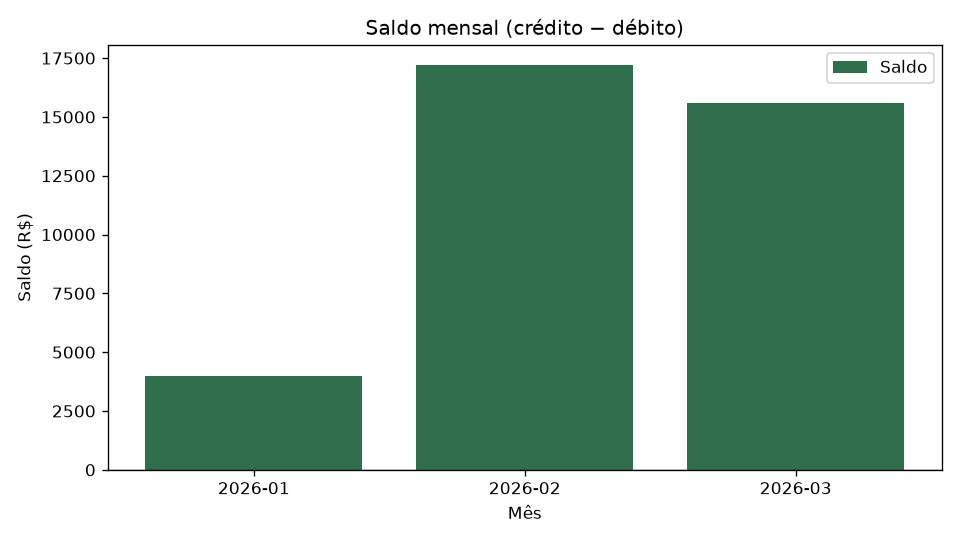

In [8]:
# ===== CÉLULA DE EXECUÇÃO PRINCIPAL =====
brutas = ler_transacoes("transacoes.csv")
total_lidas = len(brutas)
validas = []
for linha in brutas:
    limpa = validar_transacao(linha)
    if limpa is not None:
        validas.append(limpa)

total_validas = len(validas)
total_invalidas = total_lidas - total_validas

if total_lidas == 0:
    print("Sem dados para processar.")
elif total_validas == 0:
    print("===== LIMPEZA DOS DADOS =====")
    print(f"Total de linhas lidas: {total_lidas}")
    print(f"Linhas válidas: {total_validas}")
    print(f"Linhas inválidas: {total_invalidas}")
    print("Nenhuma transação válida para gerar relatório.")
else:
    relatorio = gerar_relatorio(validas)
    exibir_relatorio(total_lidas, total_validas, total_invalidas, relatorio)
    salvar_json(total_validas, total_invalidas, relatorio)
    gerar_grafico_saldo(relatorio["resumo_mensal"])
    from IPython.display import Image, display
    display(Image(filename="grafico.png"))


## RO1 — pandas

Esta célula fica separada da solução nativa. O mesmo cálculo está em `analise_pandas.py` para rodar no terminal com `python analise_pandas.py` depois que `relatorio.json` existir.


In [9]:
import pandas as pd

df = pd.read_csv("transacoes.csv", dtype=str)
df["id"] = pd.to_numeric(df["id"], errors="coerce")
df["valor"] = pd.to_numeric(df["valor"], errors="coerce")
df["data"] = pd.to_datetime(df["data"], format="%Y-%m-%d", errors="coerce")
df["cliente_id"] = df["cliente_id"].fillna("").str.strip()
df["tipo"] = df["tipo"].fillna("").str.strip().str.lower()

mask = (
    df["id"].notna()
    & df["cliente_id"].ne("")
    & df["data"].notna()
    & df["tipo"].isin(["credito", "debito"])
    & df["valor"].notna()
    & (df["valor"] > 0)
)
limpo = df.loc[mask].copy()
limpo["mes"] = limpo["data"].dt.strftime("%Y-%m")

pandas_resumo = {}
for mes, grupo in limpo.groupby("mes", sort=True):
    credito = float(grupo.loc[grupo["tipo"] == "credito", "valor"].sum())
    debito = float(grupo.loc[grupo["tipo"] == "debito", "valor"].sum())
    pandas_resumo[mes] = {
        "quantidade": int(len(grupo)),
        "total_credito": round(credito, 2),
        "total_debito": round(debito, 2),
        "saldo": round(credito - debito, 2),
        "media": round(float(grupo["valor"].mean()), 2),
        "maior_valor": float(grupo["valor"].max()),
        "menor_valor": float(grupo["valor"].min()),
    }

with open("relatorio.json", encoding="utf-8") as arquivo:
    nativo = json.load(arquivo)["resumo_mensal"]

print("===== COMPARAÇÃO PANDAS =====")
divergencias = []
for mes, m in pandas_resumo.items():
    print(
        f"{mes}: q={m['quantidade']} credito={m['total_credito']} "
        f"debito={m['total_debito']} saldo={m['saldo']}"
    )
    ref = nativo.get(mes)
    if ref is None:
        divergencias.append(f"{mes} ausente no JSON nativo")
        continue
    for chave, valor in m.items():
        if chave == "quantidade":
            if int(valor) != int(ref[chave]):
                divergencias.append(f"{mes}.{chave}: {valor} != {ref[chave]}")
        elif abs(float(valor) - float(ref[chave])) > 0.01:
            divergencias.append(f"{mes}.{chave}: {valor} != {ref[chave]}")

if set(pandas_resumo) != set(nativo):
    divergencias.append("os meses dos dois resumos diferem")

if divergencias:
    print("DIVERGÊNCIAS:")
    for item in divergencias:
        print(f" - {item}")
else:
    print("OK: resultados iguais (pandas == relatorio.json)")


===== COMPARAÇÃO PANDAS =====
2026-01: q=5 credito=4700.0 debito=720.4 saldo=3979.6
2026-02: q=5 credito=17800.0 debito=595.0 saldo=17205.0
2026-03: q=6 credito=16400.0 debito=809.9 saldo=15590.1
OK: resultados iguais (pandas == relatorio.json)
